# Разведочный анализ данных (EDA)

**Цель:** исследовать синтетический датасет задержек авиарейсов, выявить закономерности.

**Данные:** `data/flights.csv`

**Основные выводы:**
- Вечерние рейсы (16–20 ч) задерживаются сильнее утренних — эффект накопления задержек
- В выходные дни задержки меньше
- Авиакомпании заметно различаются по средней задержке
- Распределение задержек скошено вправо

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
df = pd.read_csv('../data/raw/flights.csv')
df['DEP_HOUR'] = (df['SCHEDULED_DEPARTURE'] // 100).clip(0, 23)
print(f"Записей: {len(df)}, колонок: {df.shape[1]}")
df.head(3)

Записей: 50000, колонок: 12


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DISTANCE,CANCELLED,DEP_HOUR,DEPARTURE_DELAY
0,2025,7,28,1,DL,MSP,EWR,2155,173,0,21,16.0
1,2025,4,19,3,AA,EWR,IAH,1300,1983,0,13,7.0
2,2025,11,10,1,F9,DEN,FLL,2230,2027,0,22,11.0


In [4]:
# Пропуски и статистики
print("Пропуски:\n", df.isnull().sum())
print("\nСтатистики задержек:\n", df['DEPARTURE_DELAY'].describe())

Пропуски:
 YEAR                   0
MONTH                  0
DAY                    0
DAY_OF_WEEK            0
AIRLINE                0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_DEPARTURE    0
DISTANCE               0
CANCELLED              0
DEP_HOUR               0
DEPARTURE_DELAY        0
dtype: int64

Статистики задержек:
 count    50000.000000
mean        18.602600
std         13.031663
min          2.000000
25%          9.000000
50%         16.000000
75%         24.000000
max        123.000000
Name: DEPARTURE_DELAY, dtype: float64


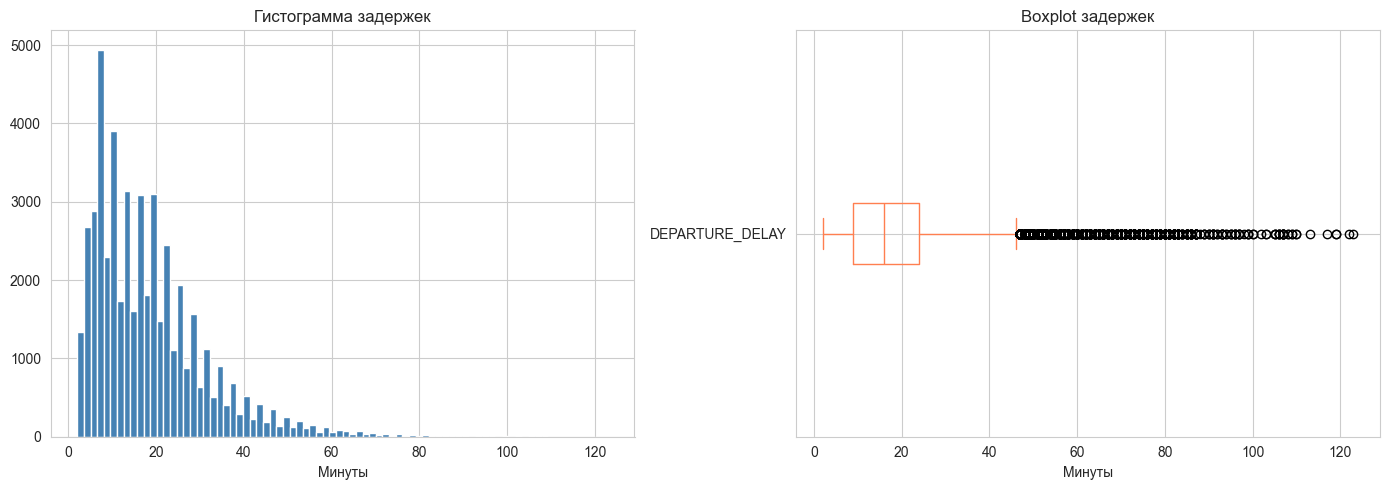

In [5]:
# Распределение задержек
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['DEPARTURE_DELAY'].clip(-30, 150).hist(bins=80, ax=axes[0], color='steelblue')
axes[0].set_title('Гистограмма задержек')
axes[0].set_xlabel('Минуты')

df['DEPARTURE_DELAY'].clip(-30, 150).plot(kind='box', ax=axes[1], vert=False, color='coral')
axes[1].set_title('Boxplot задержек')
axes[1].set_xlabel('Минуты')

plt.tight_layout()
plt.show()

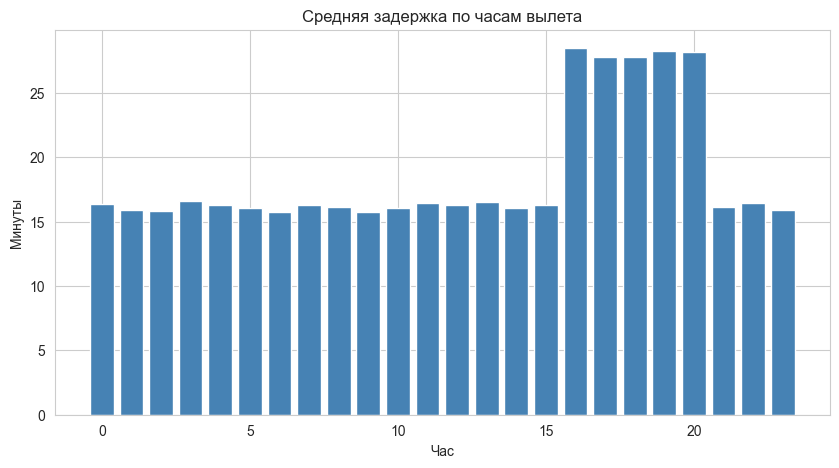

In [6]:
# Задержки по часам
hourly = df.groupby('DEP_HOUR')['DEPARTURE_DELAY'].agg(['mean', 'count'])
hourly = hourly[hourly['count'] > 100]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(hourly.index, hourly['mean'], color='steelblue')
ax.set_title('Средняя задержка по часам вылета')
ax.set_xlabel('Час')
ax.set_ylabel('Минуты')
plt.show()

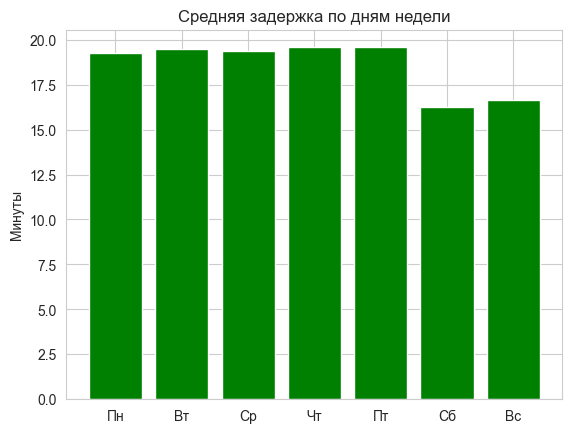

In [7]:
# Задержки по дням недели
dow = df.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY'].mean()
plt.bar(['Пн','Вт','Ср','Чт','Пт','Сб','Вс'], dow.values, color='green')
plt.title('Средняя задержка по дням недели')
plt.ylabel('Минуты')
plt.show()

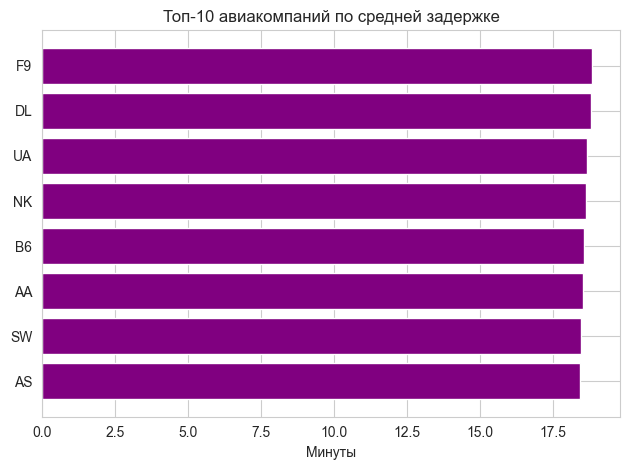

In [8]:
# Топ-10 авиакомпаний по задержкам
airline = df.groupby('AIRLINE')['DEPARTURE_DELAY'].mean().sort_values().tail(10)
plt.barh(airline.index, airline.values, color='purple')
plt.title('Топ-10 авиакомпаний по средней задержке')
plt.xlabel('Минуты')
plt.tight_layout()
plt.show()